In [1]:
!pip install -Uqq fastbook
from fastbook import *
from fastcore import *

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 36.9 MB/s eta 0:00:00


In [2]:
!pip install ddgs
from ddgs import DDGS
from fastcore.all import *

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 55.5 MB/s eta 0:00:00


In [3]:
def search_images_ddg(term,max_images=100):
    return L(DDGS().images(term,max_results=max_images)).itemgot("image")

In [4]:
urls=search_images_ddg("bird photos",max_images=1)
urls[0]

'https://images.pexels.com/photos/326900/pexels-photo-326900.jpeg?cs=srgb&dl=wood-flight-bird-326900.jpg&fm=jpg'

In [5]:
from fastdownload import download_url

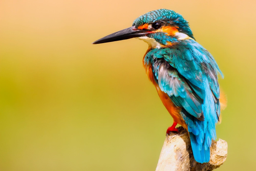

In [6]:
dest="bird.jpg"
download_url(urls[0],dest, show_progress=False)

from fastai.vision.all import *
im=Image.open(dest)
im.to_thumb(256,256)

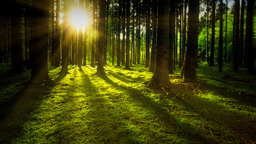

In [7]:
download_url(search_images_ddg("forest photos",max_images=1)[0],"forest.jpg", show_progress=False)
Image.open("forest.jpg").to_thumb(256,256)

In [8]:
searches="forest","bird"
path=Path('bird_or_not')
for o in searches:
    dest=(path/o)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest,urls=search_images_ddg(f'{o} photo'))
    time.sleep(5)
    resize_images(path/o,max_size=400, dest=path/o)

In [9]:
failed=verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

In [10]:
dls=DataBlock(
    blocks=(ImageBlock,CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2,seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192,method='squish')]
).dataloaders(path, bs=32)

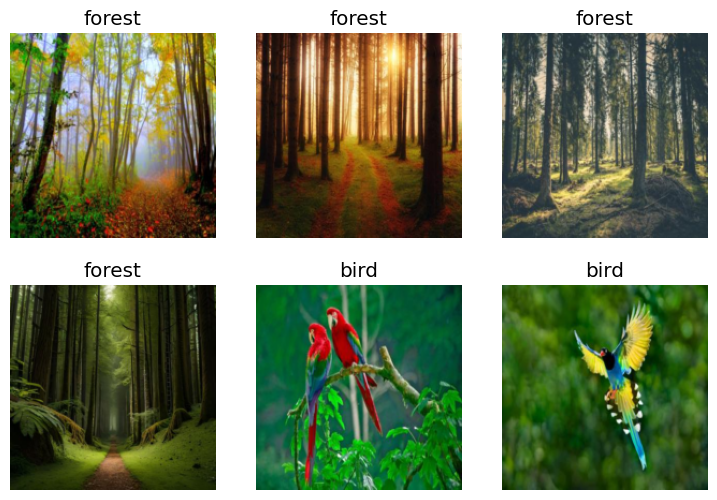

In [11]:
dls.show_batch(max_n=6)

In [12]:
learn=vision_learner(dls,resnet18,metrics=error_rate)
learn.fine_tune(3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 170MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,2.001828,0.571742,0.384615,00:02


epoch,train_loss,valid_loss,error_rate,time
0,1.029881,0.332709,0.230769,00:00
1,1.053170,0.087816,0.000000,00:00
2,0.730595,0.037285,0.000000,00:00


In [13]:
is_bird,_,prob=learn.predict(PILImage.create('bird.jpg'))
print(f"is bird:{is_bird}")
print(f"probability:{prob[0]:.4f}")

is bird:bird
probability:1.0000
